<a href="https://colab.research.google.com/github/kjahan/nlp_tips_and_trick/blob/main/notebooks/farsi_docs_translator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MT/LLM for Translation

Imagine we have a scanned doc in Korean (birth certificate). We want to translate it to Enlglish.

## Load test images

In [1]:
!mkdir data

In [2]:
import matplotlib.pyplot as plt

## Load image

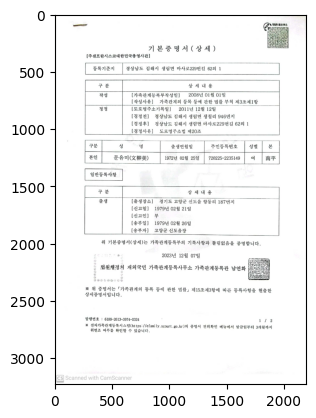

In [3]:
# Open the image file
img_1 = plt.imread("data/korean_1.jpg")

# Display the image
plt.imshow(img_1)
plt.show()

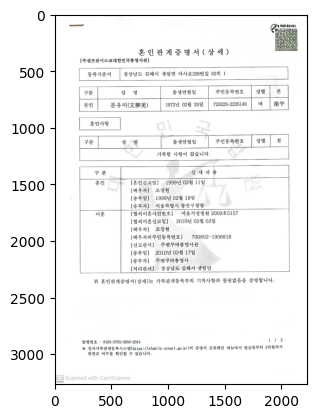

In [4]:
# Open the image file
img_2 = plt.imread("data/korean_2.jpg")

# Display the image
plt.imshow(img_2)
plt.show()

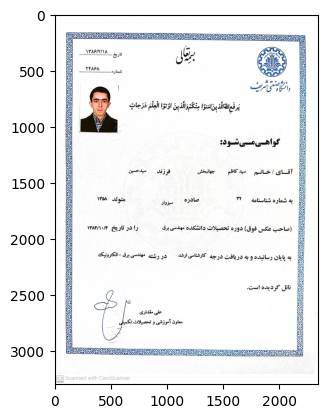

In [5]:
# Open the image file
img_3 = plt.imread("data/farsi_1.jpg")

# Display the image
plt.imshow(img_3)
plt.show()

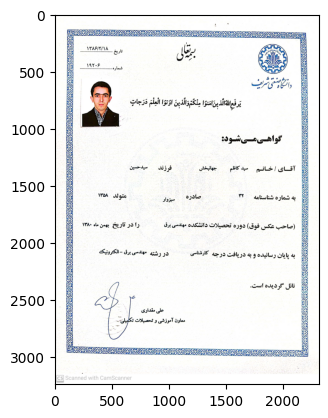

In [6]:
# Open the image file
img_4 = plt.imread("data/farsi_2.jpg")

# Display the image
plt.imshow(img_4)
plt.show()

In [7]:
images = [img_1, img_2, img_3, img_4]

## Install Terrasect

In [8]:
! apt install tesseract-ocr
! apt install libtesseract-dev
! pip install Pillow
! pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 24 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (6,153 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 121658 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

# Download Korean/Farsi font for OCR

https://github.com/kjahan/nlp_tips_and_trick/blob/main/notebooks/persian_textbook_image_to_text_converter.ipynb

https://github.com/kjahan/themis/blob/main/pipelines/disclosure_intel_pipeline.ipynb

https://stackoverflow.com/questions/62804846/extracting-persian-farsi-text-from-image-in-python



## Download fonts

Download fonts manually and load in the data folder. Don't use wget command since it doesnt download correctly.

https://github.com/tesseract-ocr/tessdata/blob/main/fas.traineddata

https://github.com/tesseract-ocr/tessdata/blob/main/kor.traineddata

In [9]:
import pytesseract

In [10]:
!ls /usr/share/tesseract-ocr/4.00/tessdata/

configs  eng.traineddata  osd.traineddata  pdf.ttf  tessconfigs


In [11]:
!ls -l /usr/share/tesseract-ocr/4.00/tessdata/

total 14348
drwxr-xr-x 2 root root     4096 Dec 19 14:16 configs
-rw-r--r-- 1 root root  4113088 Sep 15  2017 eng.traineddata
-rw-r--r-- 1 root root 10562727 Sep 15  2017 osd.traineddata
-rw-r--r-- 1 root root      572 Feb  9  2022 pdf.ttf
drwxr-xr-x 2 root root     4096 Dec 19 14:16 tessconfigs


In [12]:
!cp /content/data/fas.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/
!cp /content/data/kor.traineddata  /usr/share/tesseract-ocr/4.00/tessdata/

In [13]:
!ls -l /usr/share/tesseract-ocr/4.00/tessdata/

total 29860
drwxr-xr-x 2 root root     4096 Dec 19 14:16 configs
-rw-r--r-- 1 root root  4113088 Sep 15  2017 eng.traineddata
-rw-r--r-- 1 root root   561272 Dec 31 19:41 fas.traineddata
-rw-r--r-- 1 root root 15317715 Dec 31 19:41 kor.traineddata
-rw-r--r-- 1 root root 10562727 Sep 15  2017 osd.traineddata
-rw-r--r-- 1 root root      572 Feb  9  2022 pdf.ttf
drwxr-xr-x 2 root root     4096 Dec 19 14:16 tessconfigs


# Error

TesseractError: (1, 'Error opening data file /usr/share/tesseract-ocr/4.00/tessdata/fas.traineddata Please make sure the TESSDATA_PREFIX environment variable is set to your "tessdata" directory. Failed loading language \'fas\' Tesseract couldn\'t load any languages! Could not initialize tesseract.')

In [14]:
import tqdm

In [19]:
# go through each page image and run OCR
ocr_texts = []

with tqdm.tqdm(total=len(images)) as progress:
  for inx, image in enumerate(images):
    # Convert image to string
    # print(pytesseract.image_to_string(Image.open(disclouse_img)))
    if inx <= 1:
      # first two images are korean and rest farsi
      text = pytesseract.image_to_string(image, lang='kor')#, config='--psm 1')
    else:
      text = pytesseract.image_to_string(image, lang='fas', config='--psm 1')
    ocr_texts.append(text)
    progress.update(1)

100%|██████████| 4/4 [00:22<00:00,  5.61s/it]


In [20]:
test_inx = 0
ocr_texts[test_inx]

" \n\n기 본 중 명 서 ( 상 세 )\n[ 주 샌 프 란 시 스 코 대 한 민 국 총 영 사 관 ]\n\n \n\n등 록 기 준 지 경 상 남 도 김 해 시 생 림 면 마 사 로 229 번 길 628 의 1\n\n \n\n   \n \n \n\n \n      \n\n[ 가 족 관 게 등 록 부 작 성 일 ] _ 2008 년 01 월 01 일\n〔 [ 작 성 사 유 ] 가 족 관 계 의 등 록 등에 관 한 법 률 부 칙 제 3 조 제 1 항\n정 정 [ 도 로 명 주 소 기 록 일 ] _ 2011 년 1월 12 일 .\n[ 경 정 전 ] _ 경 상 남 도 김 해 시 생 림 면 생 철 리 946 먼 지\n[ 경 정 후 ] . 경 상 남 도 김 해 시 생 림 면 마 사 로 229 낸 길 62 의 1\n[ 경 정 사 유 ] . 도 로 명 주 소 법 제 20 조\n\n \n\n \n\n \n\n \n\n \n\n    \n \n\n출 생 연 월 일\n\n        \n\n \n\n유 미 (% 빼 촛 ) 1972 년 02 월 25 일 720225-2235149\n\n \n\n    \n\n  \n      \n       \n         \n\n상 세 내 용\n[ 출 생 장 소 ] 경 기 도 고 양 군 신 도 읍 향 동 리 187 번 지\n[ 신 고 일 ] _1979 년 02 월 21 일\n\n[ 신 고 인 ] _ 부\n\n[ 송 부 일 ] _1979 년 02 월 26 일\n\n송 부 자 ] 고 양 군 신 도 읍 장\n\n \n\n;\n\n \n\n \n\n위 기 본 증 명 서 ( 상 세 )\n\n디\n\n가 족 관 계 등 록 부 의 기 록 사 항 과 틀 림 없 음 을 증 명 합\n\n트\n로\n\n2023 년 12 월 07 일\n\n \n\n발 행 번 호 : 6189-2613-3974-0324 ' 1 / 2\n\n※ 전 자 가 족 관 계 등 록 시 스 템 (01108://6[890117.50001.90.) 의 증 명 서 진 위 확 인 메 뉴 에 서 발 급

In [21]:
test_inx = 1
ocr_texts[test_inx]

' \n\n혼 인 관 계 증 명 서 ( 상 세 )\n[ 주 샌 프 란 시 스 코 대 한 민 국 총 영 사 관 ]\n\n \n\n등 록 기 준 지 _ | 경 상 남 도 김 해 시 생 림 면 마 사 로 289 번 길 62 의 1 】\n\n \n\n \n\nl 출 생 연 월 일 ^l 주 민 등 록 번 호\n\n \n\n \n  \n\n   \n\n1972 년 02 월 25 일 720225-2235149\n\n \n\n \n\n주 민 등 록 번 호\n기 록 할 사 항 이 없 습 니 다 .\n\n \n\n상 세 내 용\n\n \n\n \n\n \n\n[ 혼 인 신 고 일 ] _1999 년 02 월 11 일\n[ 배 우 자 ] , 조 장 현 、\n\n[ 송 부 일 ] _ 1999 년 02 월 18 일\n\n[ 송 부 자 ] 서 울 특 별 시 광 진 구 청 장 _\n\n \n\n \n\n이 혼 [ 협 의 이 혼 사 건 번 호 ] _ 서 울 가 정 법 원 2009 호 5157\n[ 협 의 이 혼 신 고 일 ] _ 2010 년 03 월 03 일\n[ 배 우 자 ] 조 장 현\n\n[ 배 우 자 의 주 민 등 록 번 호 ] . 700802-1906818\n[ 신 고 관 서 ] ㆍ 주 밴 쿠 버 총 영 사 관\n\n[ 송 부 일 ] 2010 년 03 월 17 일\n\n[ 송 부 자 ] 주 밴 쿠 버 총 영 사\n\n[ 처 리 관 서 ] _ 경 상 남 도 김 해 시 생 림 면\n\n \n\n \n\n위 혼 인 관 계 증 명 서 ( 상 세 ) 는 가 족 관 계 등 록 부 의 기 록 사 항 과 틀 림 없 음 을 증 명 합 니 다 .\n\n발 행 번 호 : 8185-2705-3956-2014 1 / 2\n※ 전 자 가 족 관 계 등 록 시 스 템 (46(09://6[30117.8000 ㄴ 80.) 의 증 명 서 진 위 확 인 메 뉴 에 서 발 급 일 부 터 3 개 월 까 지\n위 변 조 여 부 를 확 인 할 수 있 습 니 다 .\n\x0c'

In [22]:
test_inx = 2
ocr_texts[test_inx]

'0\nع\n5\n4\nم۲\n۳\nی\n\n۹\n4۰\n\n \n\n \n\n \n\n \n    \n  \n\n۳2\n\n: ۳۴۸ 4\nشماره ای 5\nدرش وه هش اک\nراسها و یرب 5\nک\n2 ره 1 برس 7 ای ور وا ات 5\nرالد ِنَاَنوا مِْکَمْوَالّدینٌ اوْتا الم رجات 0\n2 \u200c\n۶ شود:\n\n2 گواهی می شود:\nام وم\nات ی دوم کاد و : ادن سیک 0 4\nتک \u200c و ۳۲ : ۱ ۹ : ی ۱۳۵۸ 7\n\u200c به شماره شناسنامه صادره.. \u200f برزدار متولد\n5 (صاحب عکس فوق) دوره تحصیلات دانشکده مهندسی برق را در تاریخ ۱۳۸۴/۱۰/۴ 7\n57 به پایان رسانیده و به دریافت درجه کارشناسی ارشد \u200f در رشته مهندسی برق - الکترونیکه 4\nبان ۴ ی\nلاه ناد ددده آست. 8۸\n5 نل گرد\nاک علی مقداری 2\n9 معاون آموزشی و تحصیلات 7 \u200c\n5 2\n\n۹\nرا\n\n5 سَ\n333333\n\nار ۳ ییا کیت\n\x0c'

In [23]:
test_inx = 3
ocr_texts[test_inx]

'4\n\n       \n \n\n  \n\n۰ مواظُ\n\nرا ی سا\n\nرالد ین\u200cامَنوّا نرادن اوْتوَا الم ذَرَجاتٍ\n\n  \n  \n    \n\n  \n\n3\n\n7\n\n0\n\n  \n\n   \n  \n\nگواهی می شود:\n\n   \n   \n   \n\n0\n\nآقای اخانم سمیدکاظم \u200f جهانبخش. ... فرزند. سیدحسین\n\n5 به شماره شناستامه ۳۲۰۰ تحصادده ۰ رورت + متولد ۱۳۵۹\n\n5 (صاحب عکس فوق) دوزه تحصیلات دانشکده مهندسی برق . . را در تاریخ بهمن ماه ۱۳۸۰\n\n5 به پایان رسانیده و به دریافت درجه کارشناسی در وشته مهندسی برق - الکترونیکک\n\nناائل گردیده است.\n\n  \n\n4 معاون آموزشی و تحصیلات :\n\n \n\n \n\nموی ری 3333333\n\x0c'

## Install Google translator
Update 06.12.20: A new 'official' alpha version of googletrans with a fix was released

Ref: https://stackoverflow.com/questions/52455774/googletrans-stopped-working-with-error-nonetype-object-has-no-attribute-group

https://github.com/kjahan/nlp_tips_and_trick/blob/main/notebooks/pdf_translator.ipynb

In [24]:
# !pip install googletrans==4.0.0-rc1
!pip install googletrans==3.1.0a0

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 10.5 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-3.1.0a0-py3-none-any.whl size=16352 sha256=1bead75bb60eaee7594514abe4e00be33e8ee185855612949f794a065ad32942
  Stored in directory: /root/.cache/pip/wheels/50/5d/3c/8477d0af4ca2b8b1308812c09f1930863caeebc762fe265a95
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling

## Setup Translator

In [25]:
from googletrans import Translator

# translator = Translator()
translator = Translator(service_urls=['translate.googleapis.com'])

## Language short names
https://meta.wikimedia.org/wiki/Template:List_of_language_names_ordered_by_code

In [ ]:
language_short_name = {'aa':'Afar','ab':'Abkhazian','af':'Afrikaans','ak':'Akan','sq':'Albanian','am':'Amharic','ar':'Arabic',
'an':'Aragonese', 'kohy':'Armenian','as':'Assamese','av':'Avaric','ae':'Avestan','ay':'Aymara','az':'Azerbaijani','ba':'Bashkir',
'bm':'Bambara','eu':'Basque','be':'Belarusian','bn':'Bengali','bh':'Bihari languages','bi':'Bislama','bo':'Tibetan','bs':'Bosnian',
'br':'Breton','bg':'Bulgarian','my':'Burmese','ca':'Catalan; Valencian','cs':'Czech','ch':'Chamorro','ce':'Chechen','zh':'Chinese',
'cu':'Church Slavic; Old Slavonic; Church Slavonic; Old Bulgarian; Old Church Slavonic','cv':'Chuvash','kw':'Cornish','co':'Corsican',
'cr':'Cree','cy':'Welsh','cs':'Czech','da':'Danish','de':'German','dv':'Divehi; Dhivehi; Maldivian','nl':'Dutch; Flemish','dz':'Dzongkha',
'el':'Greek-Modern (1453-)','en':'English','eo':'Esperanto','et':'Estonian','eu':'Basque','ee':'Ewe','fo':'Faroese','fa':'Persian',
'fj':'Fijian','fi':'Finnish','fr':'French','fy':'Western Frisian','ff':'Fulah','Ga':'Georgian','gd':'Gaelic; Scottish Gaelic','ga':'Irish',
'gl':'Galician','gv':'Manx','el':'Greek-Modern (1453-)','gn':'Guarani','gu':'Gujarati','ht':'Haitian; Haitian Creole','ha':'Hausa',
'he':'Hebrew','hz':'Herero','hi':'Hindi','ho':'Hiri Motu','hr':'Croatian','hu':'Hungarian','hy':'Armenian','ig':'Igbo','is':'Icelandic',
'io':'Ido','ii':'Sichuan Yi; Nuosu','iu':'Inuktitut','ie':'Interlingue; Occidental',
'ia':'Interlingua (International Auxiliary Language Association)','id':'Indonesian','ik':'Inupiaq','is':'Icelandic','it':'Italian',
'jv':'Javanese','ja':'Japanese','kl':'Kalaallisut; Greenlandic','kn':'Kannada','ks':'Kashmiri','ka':'Georgian','kr':'Kanuri','kk':'Kazakh',
'km':'Central Khmer','ki':'Kikuyu; Gikuyu','rw':'Kinyarwanda','ky':'Kirghiz; Kyrgyz','kv':'Komi','kg':'Kongo','ko':'Korean',
'kj':'Kuanyama; Kwanyama','ku':'Kurdish','lo':'Lao','la':'Latin','lv':'Latvian','li':'Limburgan; Limburger; Limburgish','ln':'Lingala',
'lt':'Lithuanian','lb':'Luxembourgish; Letzeburgesch','lu':'Luba-Katanga','lg':'Ganda','mk':'Macedonian','mh':'Marshallese',
'ml':'Malayalam','mi':'Maori','mr':'Marathi','ms':'Malay','Mi':'Micmac','mk':'Macedonian','mg':'Malagasy','mt':'Maltese',
'mn':'Mongolian','mi':'Maori','ms':'Malay','my':'Burmese','na':'Nauru','nv':'Navajo; Navaho','nr':'Ndebele-South; South Ndebele',
'nd':'Ndebele-North; North Ndebele','ng':'Ndonga','ne':'Nepali','nl':'Dutch; Flemish','nn':'Norwegian Nynorsk; Nynorsk:Norwegian',
'nb':'Bokmål-Norwegian; Norwegian Bokmål','no':'Norwegian','oc':'Occitan (post 1500)','oj':'Ojibwa','or':'Oriya','om':'Oromo',
'os':'Ossetian; Ossetic','pa':'Panjabi; Punjabi','fa':'Persian','pi':'Pali','pl':'Polish','pt':'Portuguese','ps':'Pushto; Pashto',
'qu':'Quechua','rm':'Romansh','ro':'Romanian; Moldavian; Moldovan','rn':'Rundi','ru':'Russian','sg':'Sango','sa':'Sanskrit',
'si':'Sinhala; Sinhalese','sk':'Slovak','sk':'Slovak','sl':'Slovenian','se':'Northern Sami','sm':'Samoan','sn':'Shona','sd':'Sindhi',
'so':'Somali','st':'Sotho-Southern','es':'Spanish; Castilian','sq':'Albanian','sc':'Sardinian','sr':'Serbian','ss':'Swati',
'su':'Sundanese','sw':'Swahili','sv':'Swedish','ty':'Tahitian','ta':'Tamil','tt':'Tatar','te':'Telugu','tg':'Tajik','tl':'Tagalog',
'th':'Thai','bo':'Tibetan','ti':'Tigrinya','to':'Tonga (Tonga Islands)','tn':'Tswana','ts':'Tsonga','tk':'Turkmen','tr':'Turkish',
'tw':'Twi','ug':'Uighur; Uyghur','uk':'Ukrainian','ur':'Urdu','uz':'Uzbek','ve':'Venda','vi':'Vietnamese','vo':'Volapük','cy':'Welsh',
'wa':'Walloon','wo':'Wolof','xh':'Xhosa','yi':'Yiddish','yo':'Yoruba','za':'Zhuang; Chuang','zh':'Chinese','zu':'Zulu'}

## Translate

In [26]:
translation = translator.translate(ocr_texts[0], dest='en')

translated_text = translation.text
print(translated_text)

Basic certificate (detailed)
[Consulate General of the Republic of Korea in San Francisco]

 

Base of registration: 1, 628, Masa-ro 229beon-gil, Saengnim-myeon, Gimhae-si, Gyeongsangnam-do

 

   
 
 

 
      

[Date of creation of family register] _ January 1, 2008
〔 [Reason for writing] Article 3, Paragraph 1 of the Supplementary Provisions of the Act on Registration of Family Relationships, etc.
Correction [Road name address record date] _ January 12, 2011.
[Gyeongjeongjeon] _ 946 Munji, Saengcheol-ri, Saenglim-myeon, Gimhae-si, Gyeongsangnam-do
[After correction]. 1 of 62, 229 Masa-ro, Saengnim-myeon, Gimhae-si, Gyeongsangnam-do
[Reason for correction]. Road Name Address Article 20 of the Act

 

 

 

 

 

    
 

Birth date

        

 

Yumi (% minus candle) February 25, 1972 720225-2235149

 

    

  
      
       
         

Detail
[Place of birth] 187 Hyangdong-ri, Sindo-eup, Goyang-gun, Gyeonggi-do
[Report Date]_February 21, 1979

[Reporter]_Party

[Sending date] _Febru

## Translate 2

In [27]:
translation = translator.translate(ocr_texts[1], dest='en')

translated_text = translation.text
print(translated_text)

Marriage certificate (details)
[Consulate General of the Republic of Korea in San Francisco]

 

Registration standard _ | 1, 62, Masa-ro 289beon-gil, Saengnim-myeon, Gimhae-si, Gyeongsangnam-do 】

 

 

l Date of birth ^l Resident registration number

 

 
  

   

February 25, 1972 720225-2235149

 

 

resident registration number
There is nothing to record.

 

Detail

 

 

 

[Marriage registration date]_February 11, 1999
[Actor], Jo Jang-hyeon,

[Date of transmission] _ February 18, 1999

[Sender] Mayor of Gwangjin-gu, Seoul _

 

 

Divorce [Divorce by agreement case number] _ Seoul Family Court 2009 No. 5157
[Divorce notification date by agreement] _ March 3, 2010
[Actor] Jo Jang-hyeon

[Spouse's resident registration number]. 700802-1906818
[Reporting office] ㆍConsulate General in Vancouver

[Sending date] March 17, 2010

[Sender] Consul General in Vancouver

[Processing Office] _ Saengnim-myeon, Gimhae-si, Gyeongsangnam-do

 

 

This certifies that the above marriage certif

In [28]:
translation = translator.translate(ocr_texts[2], dest='en')

translated_text = translation.text
print(translated_text)

0
A
5
4
M2
3
Y

9
40

 

 

 

 
    
  

32

: 348 4
Number 5
Darsh Wah Hash Ek
Heads and Yarb 5
K
2 re 1 brush 7 e ver wa at 5
Raald Naanwa Mekamwaaldin Uta Alm Rajat 0
2
be 6:

2 is certified:
Mm and Wm
Second grade: Eden Sik 0 4
Tek and 32:1 9:1358 7
Born in Barzdar
5 (the owner of the above photo) studied at the Faculty of Electrical Engineering on 10/4/2014 7
57 completed and received a master's degree in the field of electrical-electronic engineering 4
Ban 4
It is Lah Nad Deddeh. 88
5 round nails
Ek Ali some 2
9 Deputy Education and Education 7
5 2

9
particle for direct object

5 Q
333333

R3 Yaya kit


In [29]:
translation = translator.translate(ocr_texts[3], dest='en')

translated_text = translation.text
print(translated_text)

4

       
 

  

0 comments

Ra and Sa

Rald Yen Amanwa Naradan Utwa Alm Dharjat

  
  
    

  

3

7

0

  

   
  

It is certified:

   
   
   

0

Mr. Akhanem Samidkazem Jahanbakhsh. ... child Syed Hussain

5 with ID number 3200, harvest 0 Rort + born in 1359

5 (Owner of the above photo) Degree in Electrical Engineering Faculty. . on the date of February 1380

5 completed and received a bachelor's degree in the field of electrical engineering - electronics

It has been achieved.

  

4 Deputy Education and Education:

 

 

Ray's hair 3333333
